<a href="https://colab.research.google.com/github/d12eek/ANN-And-DL-Lab-24mcs005/blob/main/Ann_And_DL_grad_cam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from PIL import Image

import cv2
from tqdm import tqdm

In [ ]:
dataset_path ='/content/drive/MyDrive/Car-Bike-Dataset'
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.125, 0.125, 0.125])
])

In [ ]:
class CustomImageDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.images = []
        self.labels = []
        self.class_names = sorted(os.listdir(root_dir))
        self.class_to_idx = {cls: idx for idx, cls in enumerate(self.class_names)}

        for cls in self.class_names:
            class_path = os.path.join(root_dir, cls)
            if os.path.isdir(class_path):
                for file in os.listdir(class_path):
                    if file.lower().endswith(('jpg', 'jpeg', 'png')):
                        self.images.append(os.path.join(class_path, file))
                        self.labels.append(self.class_to_idx[cls])

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = Image.open(self.images[idx]).convert("RGB")
        if self.transform:
            image = self.transform(image)
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return image, label

In [ ]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self._to_linear = None

        # Dummy forward to calculate flattened size
        self._get_flatten_size()

        self.fc1 = nn.Linear(self._to_linear, 128)
        self.fc2 = nn.Linear(128, num_classes)

    def _get_flatten_size(self):
        with torch.no_grad():
            x = torch.randn(1, 3, 256, 256)
            x = self.pool(F.relu(self.conv1(x)))
            x = self.pool(F.relu(self.conv2(x)))
            self._to_linear = x.view(1, -1).shape[1]

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        self.feature_maps = self.pool(F.relu(self.conv2(x)))
        x = self.feature_maps.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

In [ ]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None

        self.target_layer.register_forward_hook(self.save_activation)
        self.target_layer.register_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output.detach()

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, input_tensor, class_idx=None):
        self.model.eval()
        output = self.model(input_tensor)
        if class_idx is None:
            class_idx = output.argmax(dim=1).item()

        self.model.zero_grad()
        output[0, class_idx].backward()

        gradients = self.gradients
        activations = self.activations

        pooled_gradients = torch.mean(gradients, dim=[0, 2, 3])
        for i in range(activations.shape[1]):
            activations[:, i, :, :] *= pooled_gradients[i]

        heatmap = torch.mean(activations, dim=1).squeeze()
        heatmap = F.relu(heatmap)
        heatmap /= torch.max(heatmap)
        return heatmap.cpu().numpy(), class_idx

In [ ]:
def show_gradcam(image_tensor, heatmap, label, pred_class, class_names):
    image_np = image_tensor.squeeze().permute(1, 2, 0).cpu().numpy()
    image_np = image_np * 0.125 + 0.5  # Unnormalize
    image_np = np.clip(image_np, 0, 1)

    heatmap_resized = cv2.resize(heatmap, (image_np.shape[1], image_np.shape[0]))
    heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
    heatmap_colored = np.float32(heatmap_colored) / 255
    superimposed = heatmap_colored[..., ::-1] + image_np
    superimposed = superimposed / superimposed.max()

    plt.figure(figsize=(6, 6))
    plt.imshow(superimposed)
    plt.title(f"True: {class_names[label]} | Predicted: {class_names[pred_class]}")
    plt.axis("off")
    plt.show()

In [ ]:
def train_model(model, dataloader, epochs=10):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    model.train()
    for epoch in range(epochs):
        total_loss = 0
        for images, labels in tqdm(dataloader, desc=f"Epoch {epoch+1}/{epochs}"):
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        print(f"Epoch {epoch+1} Loss: {total_loss/len(dataloader):.4f}")
    print("✅ Training complete!")

Epoch 1/5:  13%|█▎        | 13/100 [01:26<04:34,  3.16s/it]/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1045: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 1/5: 100%|██████████| 100/100 [05:09<00:00,  3.10s/it]


Epoch 1 Loss: 1.3448


Epoch 2/5: 100%|██████████| 100/100 [04:09<00:00,  2.49s/it]


Epoch 2 Loss: 0.2320


Epoch 3/5: 100%|██████████| 100/100 [04:21<00:00,  2.61s/it]


Epoch 3 Loss: 0.0651


Epoch 4/5: 100%|██████████| 100/100 [04:09<00:00,  2.50s/it]


Epoch 4 Loss: 0.0190


Epoch 5/5: 100%|██████████| 100/100 [04:19<00:00,  2.59s/it]
/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1830: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


Epoch 5 Loss: 0.0025
✅ Training complete!


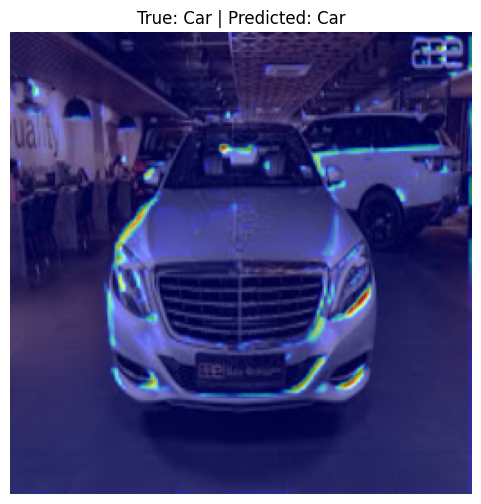

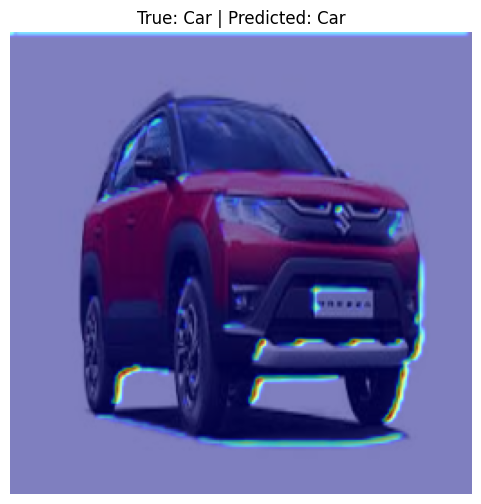

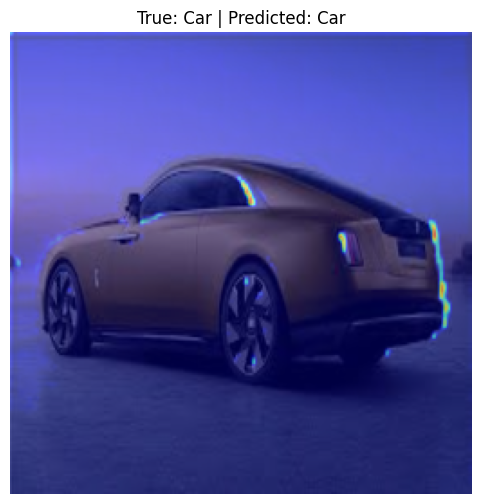

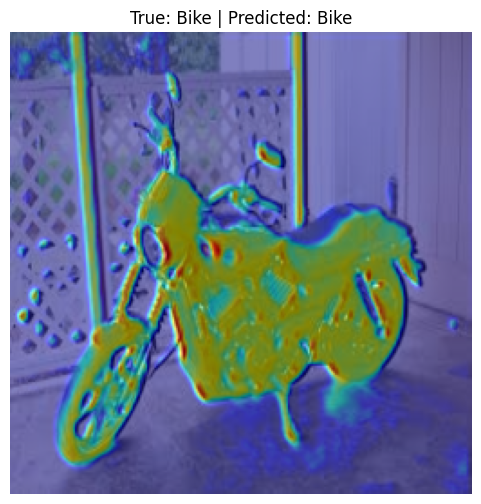

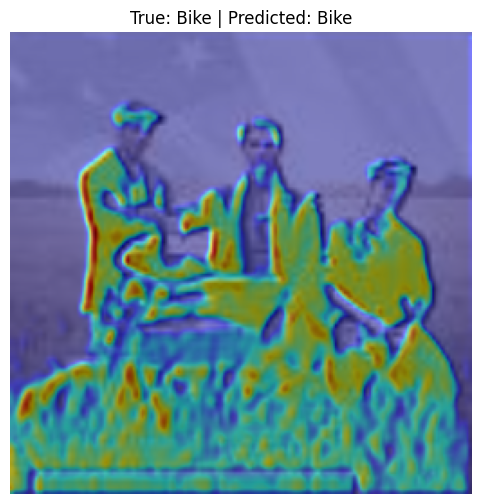


🎯 Test Accuracy: 90.12%


In [ ]:
full_dataset = CustomImageDataset(dataset_path, transform=transform)
class_names = full_dataset.class_names

# Split dataset
train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size
train_dataset, test_dataset = random_split(full_dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

# Initialize Model
model = SimpleCNN(num_classes=len(class_names)).to(device)

# Optional: Train the model (or load pre-trained weights)
train_model(model, train_loader, epochs=5)
#torch.save(model.state_dict(), "model.pth")
#model.load_state_dict(torch.load("model.pth"))

# Initialize GradCAM
gradcam = GradCAM(model, model.conv2)

# ============================
# 8. TESTING WITH GRAD-CAM (FIXED)
# ============================
model.eval()
correct = 0
total = 0

for image_tensor, label in test_loader:
    input_tensor = image_tensor.to(device)

    # Run through model *with* gradients for Grad-CAM
    output = model(input_tensor)
    pred = output.argmax(dim=1).item()

    total += 1
    correct += (pred == label.item())

    # Run Grad-CAM on first 5 examples
    if total <= 5:
        heatmap, _ = gradcam.generate(input_tensor, class_idx=pred)
        show_gradcam(image_tensor, heatmap, label.item(), pred, class_names)

accuracy = correct / total * 100
print(f"\n🎯 Test Accuracy: {accuracy:.2f}%")